# Feature Engineering Exploration

Explore spatial features, displacement features, and the novel hold usability score. Validate that features correlate with grade before modeling.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import seaborn as sns  # noqa: E402
from matplotlib.patches import FancyBboxPatch  # noqa: E402

from src.data.ingest import (  # noqa: E402
    BOARD_X_MAX,
    BOARD_X_MIN,
    BOARD_Y_MAX,
    BOARD_Y_MIN,
    load_climbs,
    load_difficulty_grades,
    load_placements,
)
from src.features.hold_usability import (  # noqa: E402
    HOLD_USABILITY_FEATURE_COLS,
    aggregate_hold_usability_features,
    compute_hold_usability,
)
from src.features.spatial import SPATIAL_FEATURE_COLS, extract_spatial_features  # noqa: E402

sns.set_theme(style="whitegrid", palette="viridis")
DB_PATH = "../data/raw/kilter.db"
grades_map = load_difficulty_grades(DB_PATH)
grade_labels = grades_map.set_index("difficulty")["boulder_name"].to_dict()

# V-grade tick helpers
vg_ticks = [t for t in sorted(grade_labels.keys()) if t % 2 == 0]
vg_tick_labels = [grade_labels[t].split("/")[1] for t in vg_ticks]


def draw_board(ax, placements_df, board_color="#e8e8e8", bolt_color="#cccccc"):
    """Draw a Kilter Board background with hold bolt positions."""
    board = FancyBboxPatch(
        (BOARD_X_MIN - 8, BOARD_Y_MIN - 4),
        BOARD_X_MAX - BOARD_X_MIN + 16,
        BOARD_Y_MAX - BOARD_Y_MIN + 8,
        boxstyle="round,pad=3",
        facecolor=board_color,
        edgecolor="#bbbbbb",
        linewidth=1.5,
    )
    ax.add_patch(board)
    ax.scatter(
        placements_df["x"],
        placements_df["y"],
        c=bolt_color,
        s=12,
        alpha=0.4,
        zorder=1,
        marker="o",
    )
    ax.set_xlim(BOARD_X_MIN - 15, BOARD_X_MAX + 15)
    ax.set_ylim(BOARD_Y_MIN - 10, BOARD_Y_MAX + 10)
    ax.set_aspect("equal")
    ax.set_facecolor("white")
    return ax

In [2]:
# Load data and extract all features
climbs = load_climbs(DB_PATH, min_ascents=5)
placements = load_placements(DB_PATH)

print("Extracting spatial features...")
spatial = extract_spatial_features(climbs, placements)

print("Computing hold usability scores...")
hold_scores = compute_hold_usability(climbs, placements)
usability = aggregate_hold_usability_features(climbs, hold_scores)

# Merge spatial + usability into single feature matrix
features = spatial.merge(usability, on="climb_uuid")
all_feature_cols = SPATIAL_FEATURE_COLS + HOLD_USABILITY_FEATURE_COLS

print(f"Feature matrix: {features.shape[0]:,} routes × {len(all_feature_cols)} features")
print(f"NaN count: {features[all_feature_cols].isna().sum().sum()}")
features[all_feature_cols + ["grade"]].describe().round(2)

Extracting spatial features...
Computing hold usability scores...
Feature matrix: 242,894 routes × 29 features
NaN count: 0


,hold_count,start_x,start_y,finish_x,finish_y,x_range,y_range,convex_hull_area,hold_density,angle,...,angle_x_avg_dx,angle_x_max_move,angle_x_hold_count,avg_hold_usability,min_hold_usability,max_hold_usability,hold_usability_range,avg_angle_sensitivity,pct_hard_holds,grade
count,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.0,...,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00,242894.00
mean,13.59,70.90,50.36,73.69,148.73,70.95,134.39,5413.69,0.00,36.8,...,889.13,2083.05,488.51,-0.95,-3.69,1.76,5.46,0.46,0.12,18.20
std,7.70,33.25,15.10,32.72,11.97,27.66,18.26,2435.32,0.00,14.6,...,483.36,1154.24,317.68,1.11,1.47,1.27,1.60,0.04,0.13,4.57
min,2.00,0.00,4.00,0.00,4.00,0.00,8.00,0.00,0.00,0.0,...,0.00,0.00,0.00,-5.38,-6.67,-3.96,0.00,0.27,0.00,10.00
25%,10.00,44.00,40.00,48.00,152.00,48.00,124.00,3760.00,0.00,30.0,...,548.57,1292.44,315.00,-1.69,-4.31,0.94,4.32,0.45,0.00,14.83
50%,12.00,72.00,48.00,72.00,152.00,68.00,144.00,5104.00,0.00,40.0,...,840.00,1938.66,450.00,-0.88,-3.54,1.82,5.23,0.47,0.08,18.00
75%,15.00,100.00,60.00,96.00,152.00,88.00,148.00,6592.00,0.00,45.0,...,1166.67,2692.95,600.00,-0.13,-2.65,2.63,6.41,0.49,0.18,21.94
max,306.00,144.00,152.00,144.00,152.00,144.00,148.00,19280.00,0.05,70.0,...,5280.00,8720.55,13770.00,2.88,1.44,5.99,12.66,0.58,1.00,31.00


## 1. Feature Correlation with Grade\n\nWhich features have the strongest linear relationship with route difficulty?

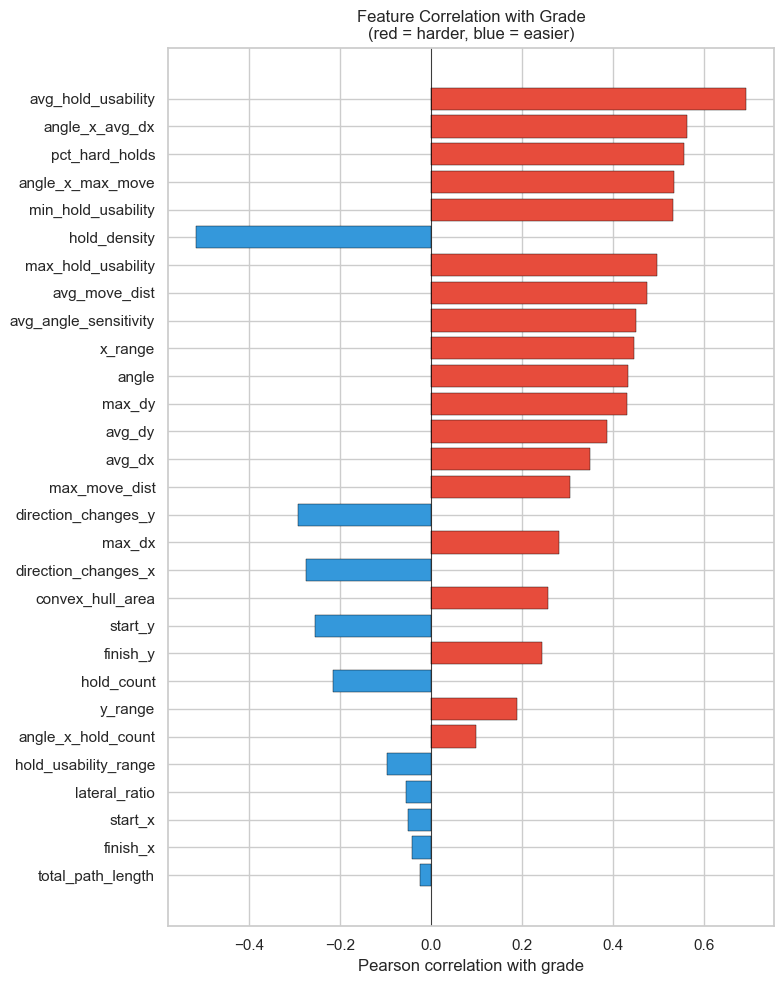

Top 10 features by |correlation| with grade:
  + avg_hold_usability: 0.692
  + angle_x_avg_dx: 0.562
  + pct_hard_holds: 0.555
  + angle_x_max_move: 0.534
  + min_hold_usability: 0.530
  - hold_density: -0.516
  + max_hold_usability: 0.495
  + avg_move_dist: 0.473
  + avg_angle_sensitivity: 0.450
  + x_range: 0.446


In [3]:
# Correlation with grade, sorted by absolute value
corr = features[all_feature_cols + ["grade"]].corr()["grade"].drop("grade")
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=True).index)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in corr_sorted]
ax.barh(corr_sorted.index, corr_sorted.values, color=colors, edgecolor="black", linewidth=0.3)
ax.set_xlabel("Pearson correlation with grade")
ax.set_title("Feature Correlation with Grade\n(red = harder, blue = easier)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 10 features by |correlation| with grade:")
for feat, val in corr.abs().sort_values(ascending=False).head(10).items():
    direction = "+" if corr[feat] > 0 else "-"
    print(f"  {direction} {feat}: {corr[feat]:.3f}")

## 2. Feature Correlation Matrix

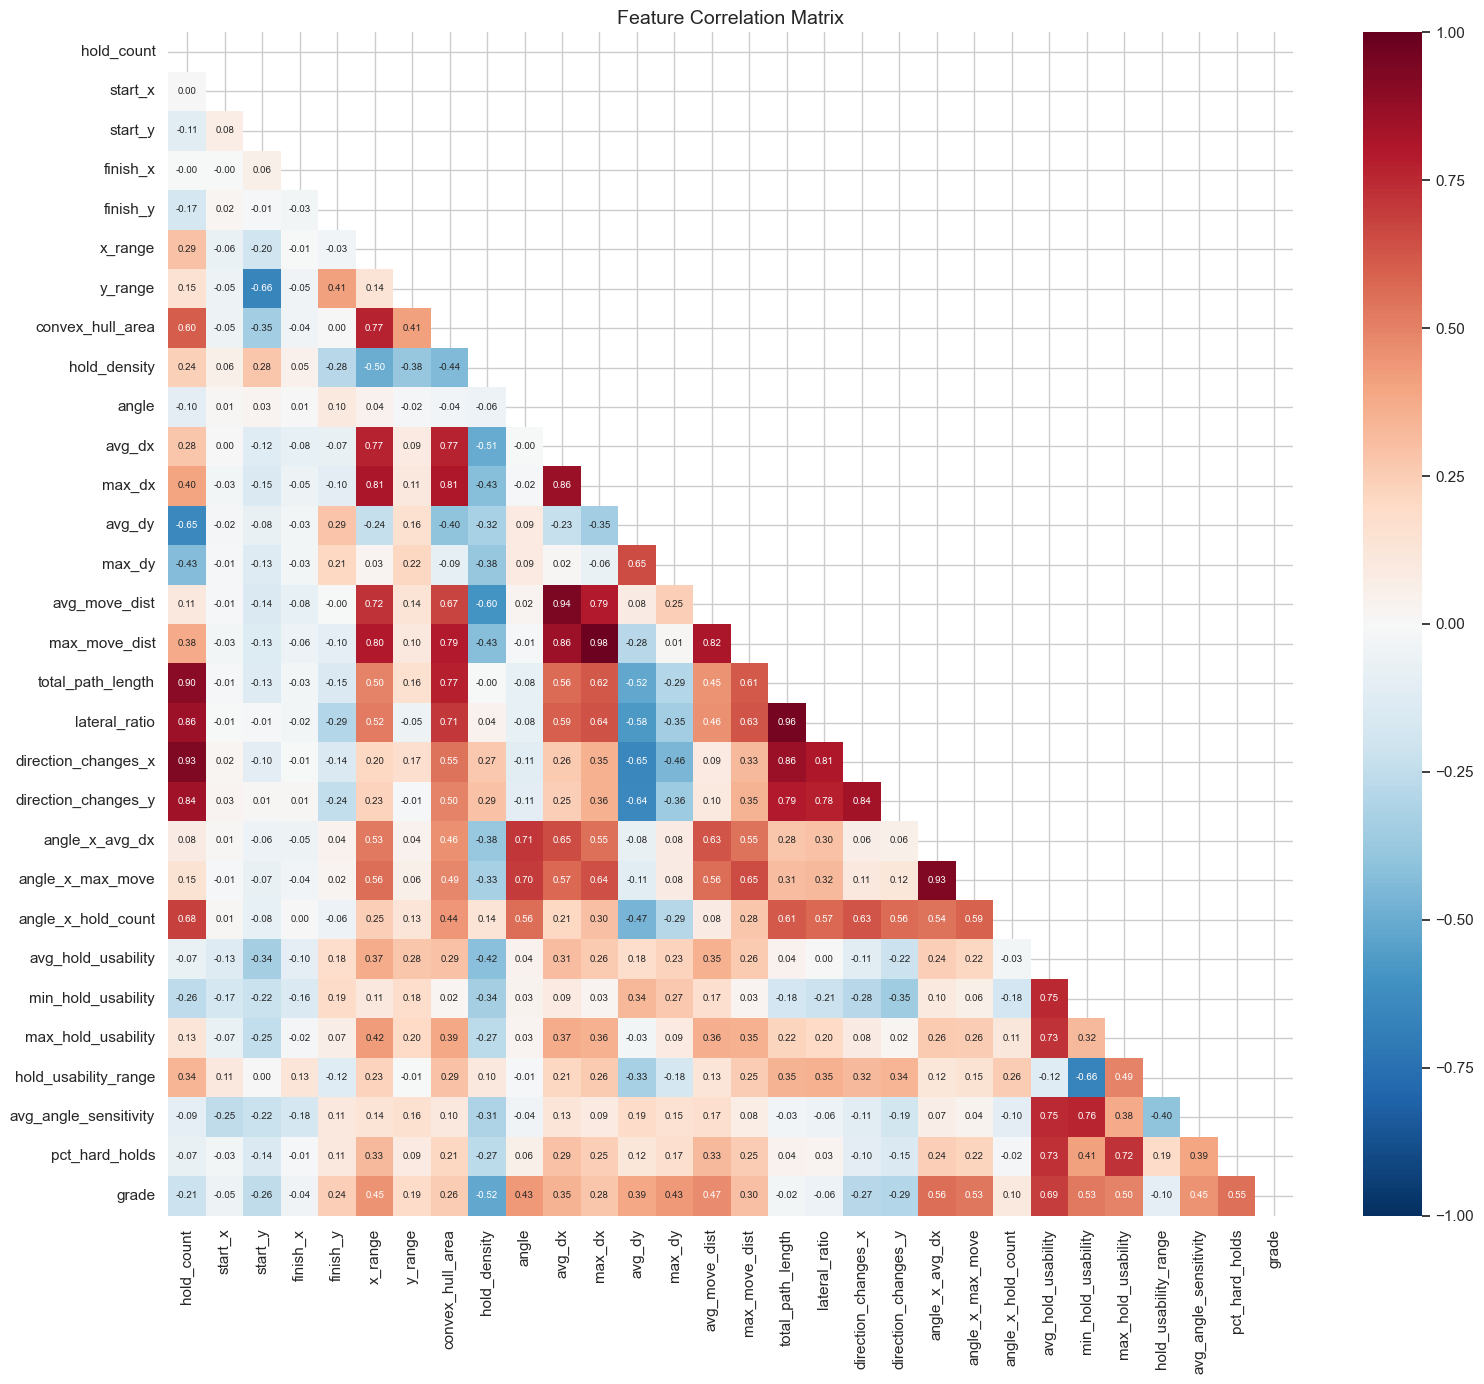

In [4]:
fig, ax = plt.subplots(figsize=(16, 14))
corr_matrix = features[all_feature_cols + ["grade"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

### Clustered Correlation Matrix

Hierarchical clustering groups features that carry similar information. Tight clusters suggest redundancy — useful for feature selection or understanding what the model "sees".

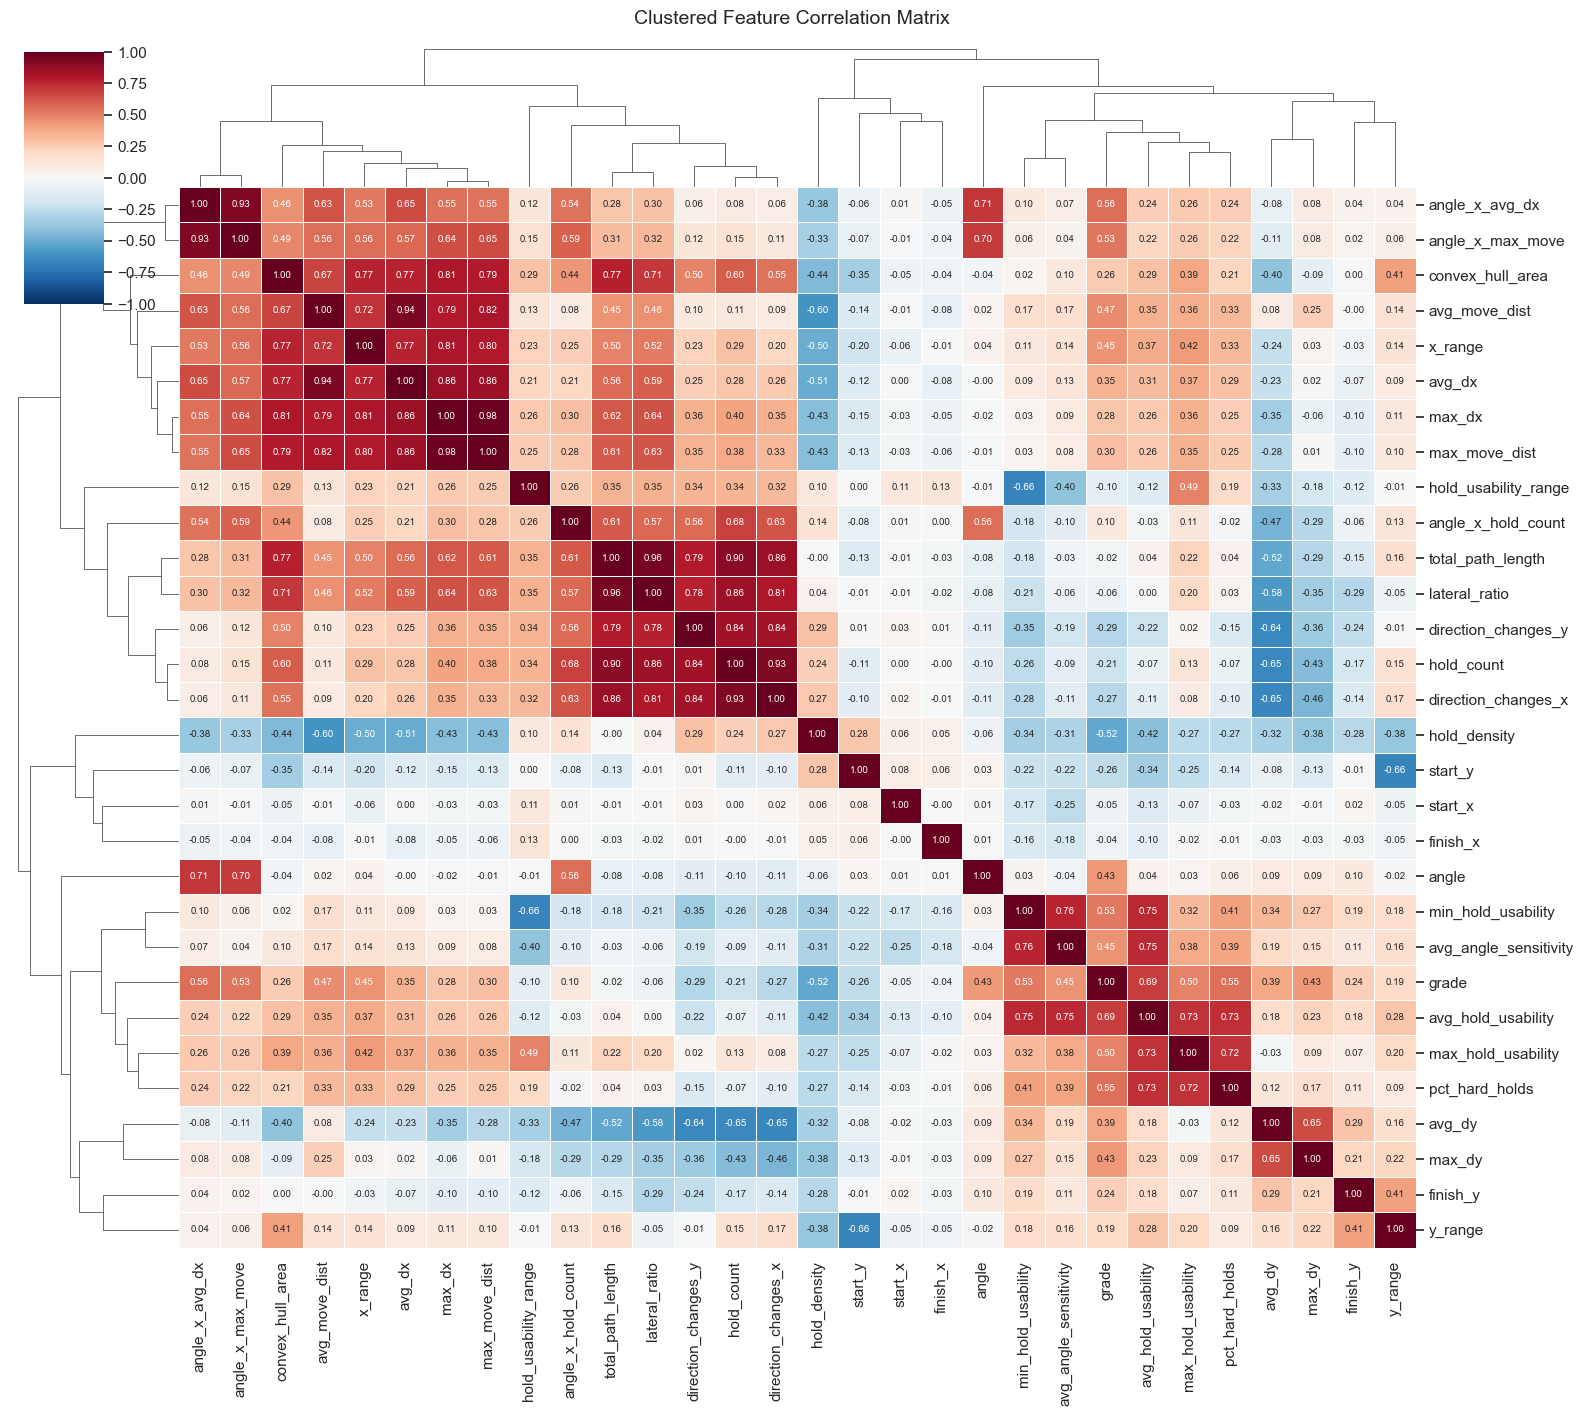

In [5]:
g = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    figsize=(16, 14),
    annot_kws={"size": 7},
    linewidths=0.5,
    dendrogram_ratio=(0.12, 0.12),
)
g.fig.suptitle("Clustered Feature Correlation Matrix", fontsize=14, y=1.01)
plt.show()

## 3. Hold Usability Heatmap on Board\n\nThe novel derived feature: each hold's \"usability\" score based on the grades of routes it appears in. Green = easy hold (jug-like), red = hard hold (crimp-like).

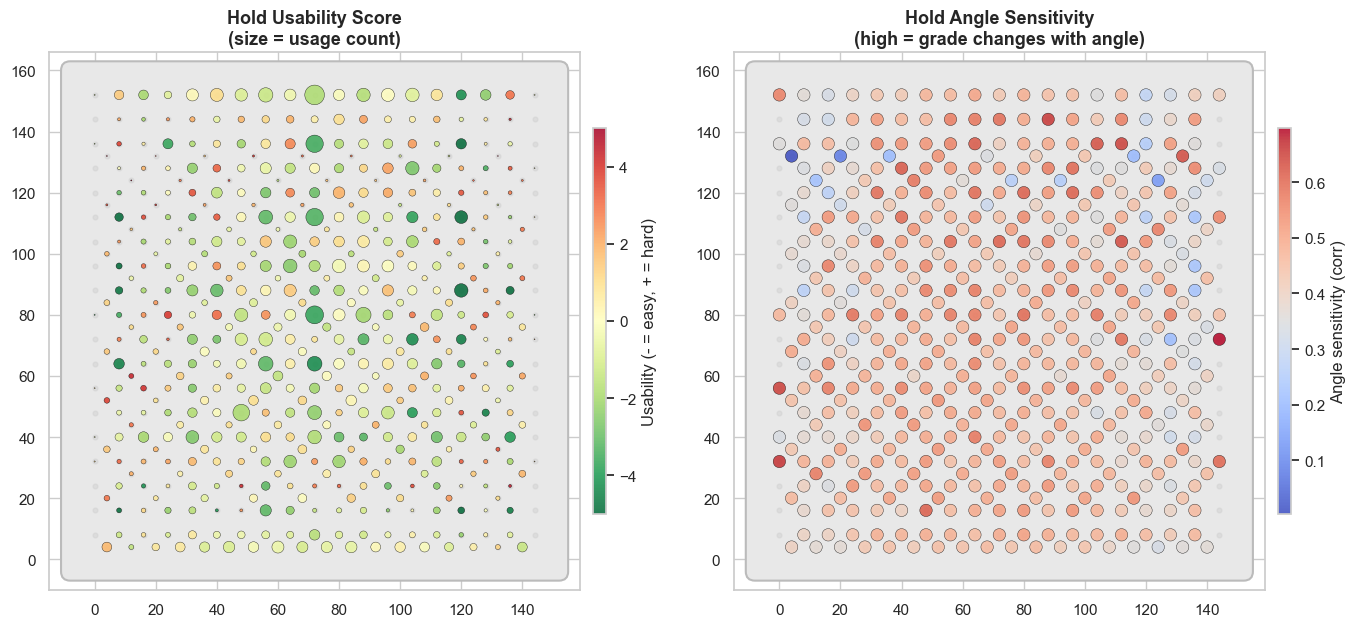

Hold usability range: -6.67 to 5.99
Mean angle sensitivity: 0.457


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Hold usability heatmap
draw_board(axes[0], placements)
scatter1 = axes[0].scatter(
    hold_scores["x"],
    hold_scores["y"],
    c=hold_scores["hold_usability"],
    s=hold_scores["hold_usage_count"] / hold_scores["hold_usage_count"].max() * 200,
    cmap="RdYlGn_r",
    vmin=-5,
    vmax=5,
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
    zorder=2,
)
axes[0].set_title("Hold Usability Score\n(size = usage count)", fontsize=13, fontweight="bold")
cbar1 = plt.colorbar(scatter1, ax=axes[0], shrink=0.4, aspect=30, pad=0.02)
cbar1.set_label("Usability (- = easy, + = hard)")

# Hold angle sensitivity heatmap
draw_board(axes[1], placements)
scatter2 = axes[1].scatter(
    hold_scores["x"],
    hold_scores["y"],
    c=hold_scores["hold_angle_sensitivity"],
    s=80,
    cmap="coolwarm",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.3,
    zorder=2,
)
axes[1].set_title(
    "Hold Angle Sensitivity\n(high = grade changes with angle)",
    fontsize=13,
    fontweight="bold",
)
plt.colorbar(
    scatter2,
    ax=axes[1],
    label="Angle sensitivity (corr)",
    shrink=0.4,
    aspect=30,
    pad=0.02,
)

plt.tight_layout()
plt.show()

u_min = hold_scores["hold_usability"].min()
u_max = hold_scores["hold_usability"].max()
print(f"Hold usability range: {u_min:.2f} to {u_max:.2f}")
print(f"Mean angle sensitivity: {hold_scores['hold_angle_sensitivity'].mean():.3f}")

## 4. Top Features vs Grade

In [ ]:
# Top 6 features by absolute correlation with grade
top_feats = corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, feat in zip(axes.flat, top_feats):
    ax.scatter(features[feat], features["grade"], alpha=0.02, s=3, color="steelblue")
    ax.set_xlabel(feat)
    ax.set_ylabel("Grade")
    r = corr[feat]
    ax.set_title(f"{feat}\nr = {r:.3f}", fontsize=11)
    # V-grade right axis
    ax_r = ax.twinx()
    ax_r.set_ylim(ax.get_ylim())
    ax_r.set_yticks(vg_ticks[::2])
    ax_r.set_yticklabels(vg_tick_labels[::2], fontsize=7)

plt.tight_layout()
plt.show()

## 5. Save Feature Matrix

In [ ]:
# Save combined feature matrix
features.to_parquet("../data/processed/features.parquet", index=False)
print(f"Saved features.parquet: {len(features):,} rows × {len(all_feature_cols)} features")

# Save per-hold usability scores
hold_scores.to_parquet("../data/processed/hold_usability.parquet", index=False)
print(f"Saved hold_usability.parquet: {len(hold_scores):,} holds")